In [33]:
pip install pca

Note: you may need to restart the kernel to use updated packages.


In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.decomposition import PCA

In [35]:
df=pd.read_csv("../Datasets/milk.csv",index_col=0)

In [36]:
scaler=StandardScaler().set_output(transform="pandas")
df_scaler=scaler.fit_transform(df)


In [37]:
pca_model=PCA().set_output(transform="pandas")
milk_pca=pca_model.fit_transform(df_scaler)

In [38]:
print(milk_pca.var())

pca0    4.040412
pca1    0.924372
pca2    0.134291
pca3    0.102689
pca4    0.006570
dtype: float64


In [39]:
print(milk_pca)

                pca0      pca1      pca2      pca3      pca4
Animal                                                      
HORSE       2.435175 -0.231478  0.330150  0.307664  0.048184
ORANGUTAN   2.258736 -0.693148  0.029035 -0.081057 -0.000532
MONKEY      2.335861 -0.663328  0.101257  0.247997  0.010109
DONKEY      2.318677 -0.273815  0.109881 -0.092873 -0.006769
HIPPO       2.060294 -1.019199 -0.762436 -0.510091  0.029382
CAMEL       1.301536  0.137303 -0.198742 -0.282160 -0.014668
BISON       1.282742  0.622667  0.253785  0.065148 -0.044486
BUFFALO     0.505068  0.088235  0.008383  0.133774  0.083806
GUINEA PIG -0.255502  0.287373 -0.881857 -0.013100 -0.016484
CAT        -0.051008  0.470136 -0.355676  1.050970  0.159793
FOX         0.429017  0.459312  0.135181  0.236941 -0.024309
LLAMA       1.364034  0.309224  0.228597 -0.088242 -0.024345
MULE        2.012658 -0.192807 -0.131325 -0.242899 -0.025286
PIG        -0.000100  0.788138 -0.334070 -0.056860 -0.056423
ZEBRA       1.390928 -0.

In [40]:
values,vectors=np.linalg.eig(df_scaler.cov())

In [41]:
print("Eigen values: \n",values)
print("Eigen  vectors: \n",vectors)

Eigen values: 
 [4.0404117 +0.j 0.92437238+0.j 0.00656977+0.j 0.13429088+0.j
 0.1026886 +0.j]
Eigen  vectors: 
 [[-0.47294379+0.j  0.35285509+0.j -0.70967042+0.j  0.36921298+0.j
   0.10893632+0.j]
 [ 0.46657047+0.j  0.32094099+0.j -0.1930657 +0.j  0.15196177+0.j
  -0.78672876+0.j]
 [ 0.44868269+0.j -0.47603724+0.j -0.66831106+0.j -0.30699163+0.j
   0.17660367+0.j]
 [-0.48289116+0.j  0.05951482+0.j -0.11159049+0.j -0.77642589+0.j
  -0.38468756+0.j]
 [ 0.35232959+0.j  0.73643513+0.j  0.00118661+0.j -0.378825  +0.j
   0.43590982+0.j]]


In [46]:
pca_model.components_

array([[ 0.47294379, -0.46657047, -0.44868269,  0.48289116, -0.35232959],
       [ 0.35285509,  0.32094099, -0.47603724,  0.05951482,  0.73643513],
       [-0.36921298, -0.15196177,  0.30699163,  0.77642589,  0.378825  ],
       [-0.10893632,  0.78672876, -0.17660367,  0.38468756, -0.43590982],
       [ 0.70967042,  0.1930657 ,  0.66831106,  0.11159049, -0.00118661]])

In [ ]:
import matplotlib.pyplot as plt
from pca import pca

[04-08-2026 11:27:05] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[04-08-2026 11:27:05] [pca.pca] [INFO] Fit using PCA.
[04-08-2026 11:27:05] [pca.pca] [INFO] Compute loadings and PCs.
[04-08-2026 11:27:05] [pca.pca] [INFO] Compute explained variance.
[04-08-2026 11:27:05] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[04-08-2026 11:27:05] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[04-08-2026 11:27:05] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[04-08-2026 11:27:05] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[04-08-2026 11:27:05] [scatterd.scatterd] [INFO] Create scatterplot


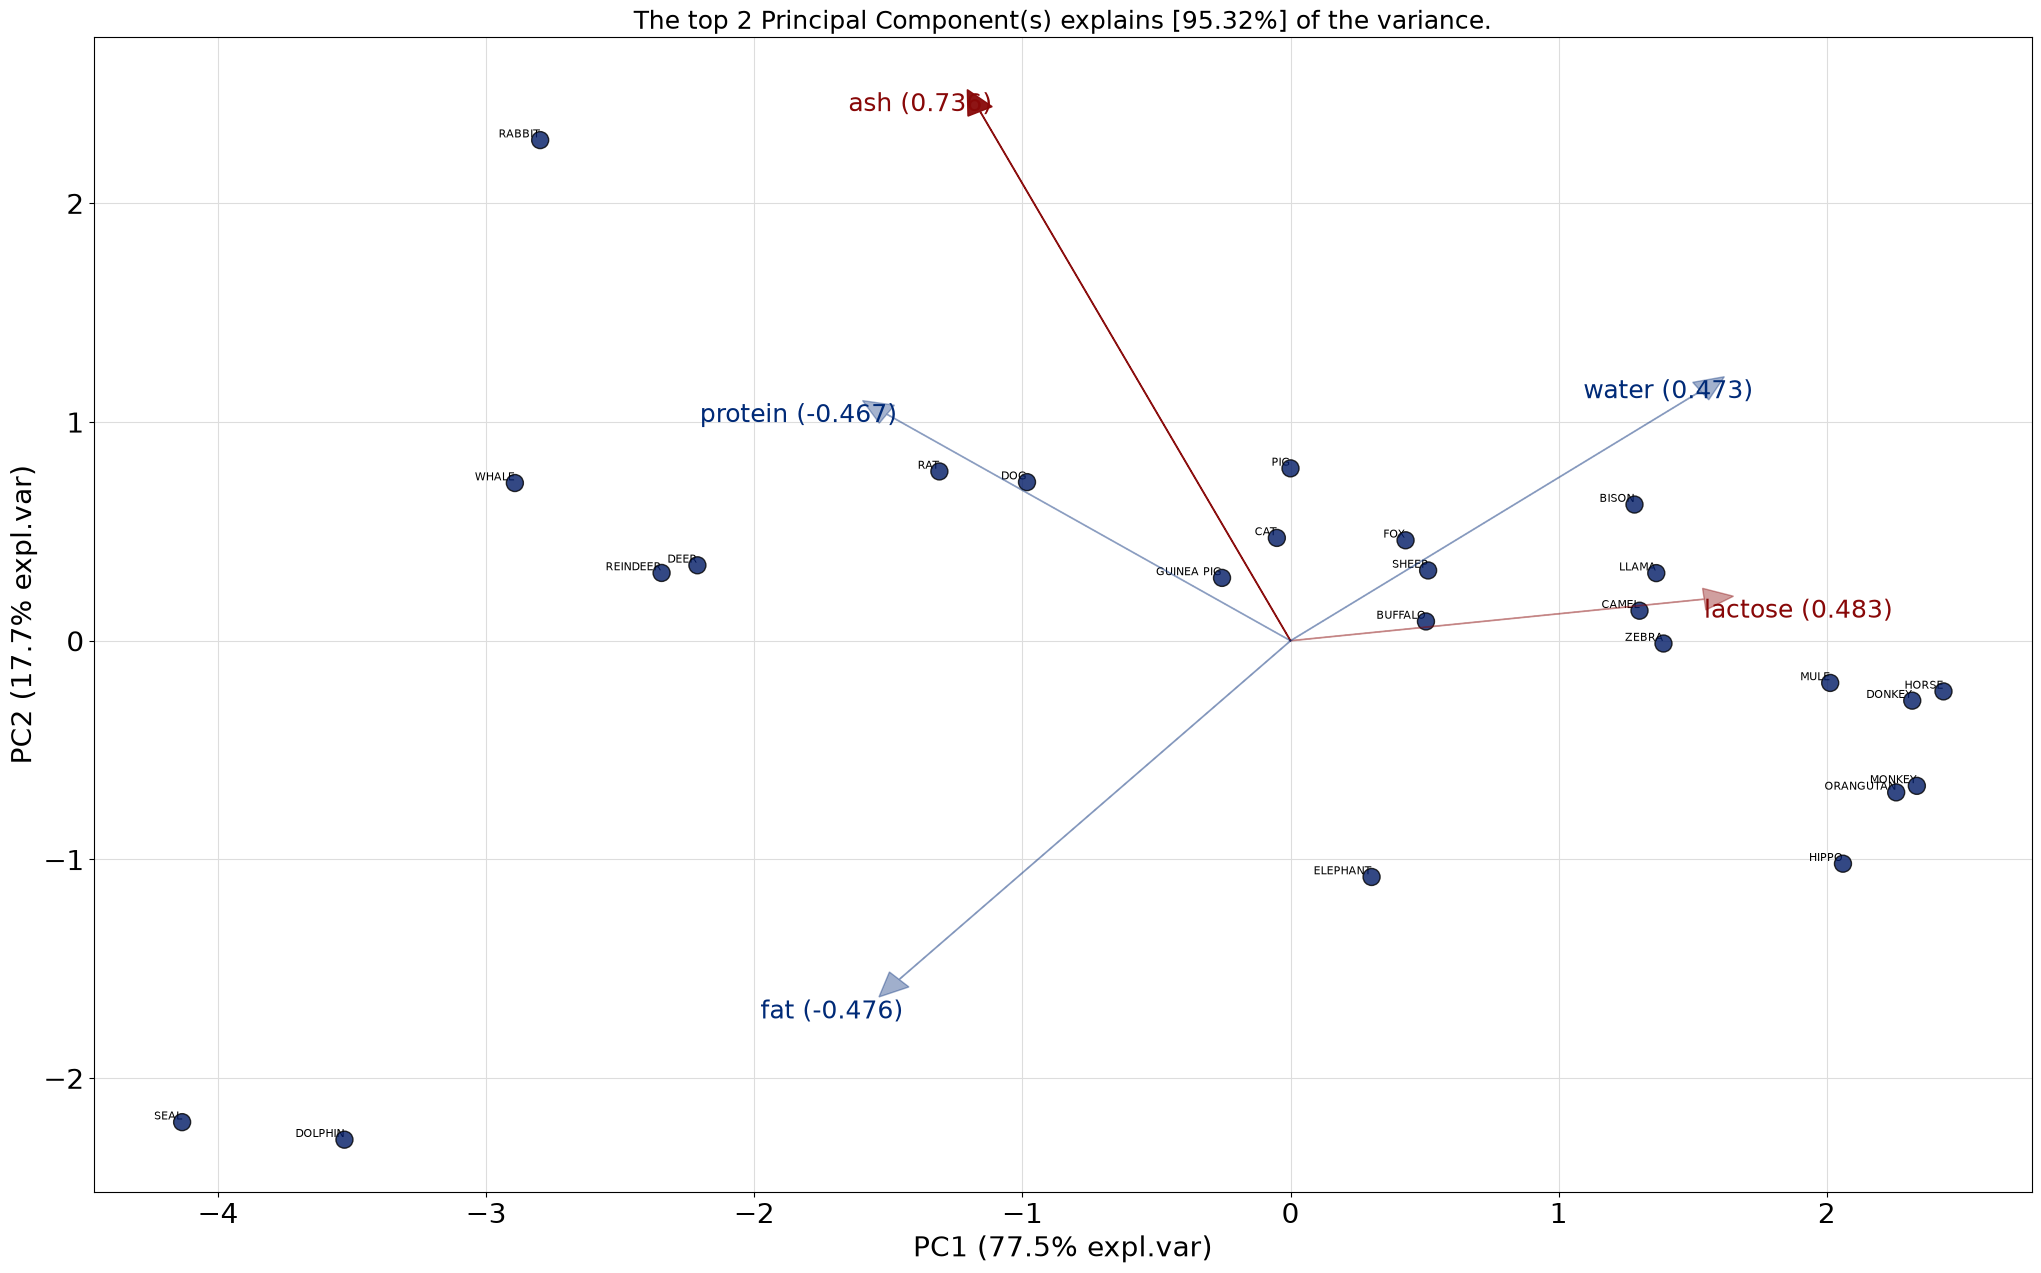

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from pca import pca

# 1. Initialize PCA model
model = pca(n_components=2)

# 2. Fit and transform
results = model.fit_transform(
    df_scaler,
    col_labels=df.columns,
    row_labels=list(df.index)
)

# 3. Create biplot (Set labels=None or omit it entirely)
fig, ax = model.biplot(legend=True)

# 4. If you want manual text annotations (Optional)
# Extract principal components DataFrame from results
pca_coords = results['PC'].values  # Matrix of PC scores

for i in range(df.shape[0]):
    x = pca_coords[i, 0]  # PC1 coordinate
    y = pca_coords[i, 1]  # PC2 coordinate
    label = df.index[i]   # Index name for row i

    # Correct syntax: plt.text(x_coordinate, y_coordinate, string_text)
    plt.text(x, y, str(label), fontsize=8, ha='right', va='bottom')

plt.show()





In [43]:
print(pca_model.explained_variance_)

[4.0404117  0.92437238 0.13429088 0.1026886  0.00656977]


In [44]:
print(pca_model.explained_variance_ratio_)

[0.77575905 0.1774795  0.02578385 0.01971621 0.0012614 ]


In [47]:
print(pca_model.explained_variance_ratio_*100)

[77.57590469 17.74794969  2.57838496  1.97162103  0.12613963]


In [48]:
print(np.cumsum(pca_model.explained_variance_ratio_*100))

[ 77.57590469  95.32385438  97.90223934  99.87386037 100.        ]
